# Map config — `apartment_complex_v1` (mới hoàn toàn)

Cấu hình toạ độ một **tầng hành lang chung cư lớn** để bạn tự đưa vào hệ thống
test điều hướng. Notebook này **chỉ chứa dữ liệu toạ độ + hình minh hoạ**, không
có code thuật toán.

**Địa hình:**
- Hành lang chính hình **chữ T**, rộng **2.0 m** (5 ô × 0.40 m).
- Nhiều **ngách thẳng vuông góc** rẽ vào cửa căn hộ.
- **Hành lang vòng cung** (2 cung nối thành vòng) **bao quanh giếng trời** ở giữa.
- **Dock biệt lập** (phòng kỹ thuật) — tường kín, **chỉ 1 cửa hẹp** ra hành lang.
- **4 điểm đến** (cửa căn hộ) nằm sâu trong ngách thẳng + trên vòng cung, xa dock.
- **3 quỹ đạo tuần tra của cư dân** (waypoint loops) dọc hành lang.

Hệ quy chiếu: lưới `rows×cols`, mỗi ô `cell_size_m`; tâm ô (r,c) trong toạ độ
thế giới = `(origin_x+(c+0.5)*cell, origin_y+(r+0.5)*cell)`.

## 1. Sinh & in cấu hình toạ độ đầy đủ (JSON)

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath("."))
from apartment_complex_map import export_config
CONFIG = export_config()            # also returns the dict
print(json.dumps(CONFIG, indent=2, ensure_ascii=False))

{
  "name": "apartment_complex_v1",
  "map_bounds_world": {
    "xmin": -13.200000000000001,
    "xmax": 13.200000000000001,
    "ymin": -11.200000000000001,
    "ymax": 11.200000000000001
  },
  "grid": {
    "rows": 54,
    "cols": 64,
    "cell_size_m": 0.4,
    "origin_world_xy": [
      -12.8,
      -10.8
    ],
    "cell_center_formula": "x=origin_x+(c+0.5)*cell ; y=origin_y+(r+0.5)*cell"
  },
  "corridors_cells": {
    "horizontal_spine": {
      "r0": 30,
      "r1": 34,
      "c0": 5,
      "c1": 58
    },
    "vertical_branch": {
      "c0": 28,
      "c1": 32,
      "r0": 8,
      "r1": 34
    },
    "width_m": 2.0,
    "apartment_niches_off_spine": [
      {
        "col": 10,
        "dir": "up",
        "depth_cells": 7
      },
      {
        "col": 16,
        "dir": "down",
        "depth_cells": 6
      },
      {
        "col": 22,
        "dir": "up",
        "depth_cells": 6
      },
      {
        "col": 52,
        "dir": "up",
        "depth_cells": 7
      },

## 2. Các nhóm toạ độ (tách riêng cho dễ dùng)

In [2]:
print("== Giới hạn map (world) ==");            print(CONFIG["map_bounds_world"])
print("\n== Lưới ==");                             print(CONFIG["grid"])
print("\n== Hành lang (ô đi được) ==")
print("  spine ngang:", CONFIG["corridors_cells"]["horizontal_spine"])
print("  nhánh dọc  :", CONFIG["corridors_cells"]["vertical_branch"])
print("  rộng (m)   :", CONFIG["corridors_cells"]["width_m"])
print("  ngách spine:", CONFIG["corridors_cells"]["apartment_niches_off_spine"])
print("  ngách nhánh:", CONFIG["corridors_cells"]["apartment_niches_off_branch"])
print("  vòng cung quanh giếng trời:", CONFIG["corridors_cells"]["curved_ring_around_lightwell"])
print("\n== Dock biệt lập ==");                    print(CONFIG["dock_isolated"])
print("\n== Điểm đến (cửa căn hộ) ==")
for k, v in CONFIG["destinations"].items(): print(f"  D{k}: {v}")
print("\n== Quỹ đạo cư dân (patrol) ==")
for i, r in enumerate(CONFIG["resident_patrols"]):
    print(f"  resident {i+1}: cells={r['waypoints_cells']}")
    print(f"             world={[ [round(x,2),round(y,2)] for x,y in r['waypoints_world'] ]}")

== Giới hạn map (world) ==
{'xmin': -13.200000000000001, 'xmax': 13.200000000000001, 'ymin': -11.200000000000001, 'ymax': 11.200000000000001}

== Lưới ==
{'rows': 54, 'cols': 64, 'cell_size_m': 0.4, 'origin_world_xy': [-12.8, -10.8], 'cell_center_formula': 'x=origin_x+(c+0.5)*cell ; y=origin_y+(r+0.5)*cell'}

== Hành lang (ô đi được) ==
  spine ngang: {'r0': 30, 'r1': 34, 'c0': 5, 'c1': 58}
  nhánh dọc  : {'c0': 28, 'c1': 32, 'r0': 8, 'r1': 34}
  rộng (m)   : 2.0
  ngách spine: [{'col': 10, 'dir': 'up', 'depth_cells': 7}, {'col': 16, 'dir': 'down', 'depth_cells': 6}, {'col': 22, 'dir': 'up', 'depth_cells': 6}, {'col': 52, 'dir': 'up', 'depth_cells': 7}, {'col': 56, 'dir': 'down', 'depth_cells': 6}]
  ngách nhánh: [{'row': 14, 'dir': 'left', 'depth_cells': 6}, {'row': 22, 'dir': 'right', 'depth_cells': 6}]
  vòng cung quanh giếng trời: {'center_cell': [18, 44], 'radius_cells': 6, 'lightwell_block': {'cr': 18, 'cc': 44, 'half': 3}, 'note': 'two connected arcs (0-180 and 180-360) form a l

## 3. Toạ độ KHÔNG GIAN HÀNH LANG (mọi ô robot đi được)

In [3]:
from apartment_complex_map import build
import numpy as np
M = build(); g = M["grid"]
free_cells = [(int(r), int(c)) for r, c in zip(*np.where(g == 1))]
print(f"số ô đi được (free cells): {len(free_cells)}")
print("ví dụ 20 ô đầu (r,c):", free_cells[:20])
# world-coord list also available:
ox, oy = M["origin"]; cell = M["cell"]
free_world = [(round(ox+(c+0.5)*cell,2), round(oy+(r+0.5)*cell,2)) for r,c in free_cells]
print("ví dụ 5 toạ độ world:", free_world[:5])

số ô đi được (free cells): 785
ví dụ 20 ô đầu (r,c): [(8, 28), (8, 29), (8, 30), (8, 31), (8, 32), (9, 28), (9, 29), (9, 30), (9, 31), (9, 32), (10, 28), (10, 29), (10, 30), (10, 31), (10, 32), (11, 28), (11, 29), (11, 30), (11, 31), (11, 32)]
ví dụ 5 toạ độ world: [(-1.4, -7.4), (-1.0, -7.4), (-0.6, -7.4), (-0.2, -7.4), (0.2, -7.4)]


## 4. Hình minh hoạ map

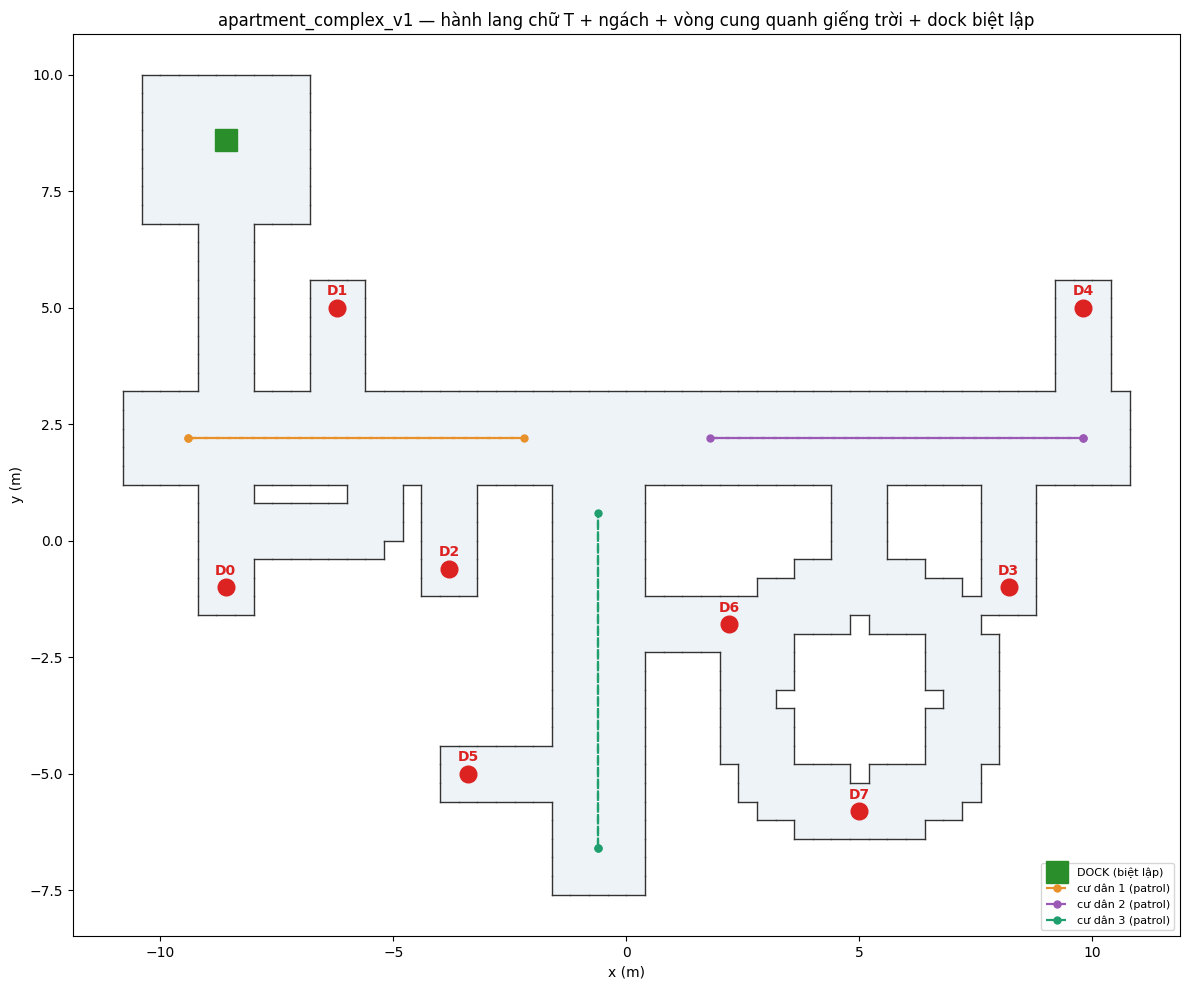

In [4]:
import matplotlib.pyplot as plt, numpy as np
w = M["world"]
fig, ax = plt.subplots(figsize=(12, 10))
# free space (light) + walls (segments)
ox, oy = M["origin"]; cell = M["cell"]
for (r, c) in free_cells:
    ax.add_patch(plt.Rectangle((ox+c*cell, oy+r*cell), cell, cell,
                               facecolor="#eef3f7", edgecolor="none"))
for (x1, y1, x2, y2) in w.segments:
    ax.plot([x1, x2], [y1, y2], color="#333", lw=1.0)
# dock, destinations, patrols
ax.plot(*M["dock"], "s", color="#2a8f2a", ms=16, label="DOCK (biệt lập)")
for k, xy in M["points"].items():
    ax.plot(*xy, "o", color="#d22", ms=12)
    ax.annotate(f"D{k}", xy, textcoords="offset points", xytext=(0, 9),
                ha="center", weight="bold", color="#d22")
colors = ["#e8902a", "#9b59b6", "#1f9e6e"]
for i, route in enumerate(M["ped_routes"]):
    a = np.array(route)
    ax.plot(a[:, 0], a[:, 1], "--o", color=colors[i % 3], lw=1.6, ms=5,
            label=f"cư dân {i+1} (patrol)")
ax.set_aspect("equal"); ax.legend(loc="lower right", fontsize=8)
ax.set_title("apartment_complex_v1 — hành lang chữ T + ngách + vòng cung quanh giếng trời + dock biệt lập")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
plt.tight_layout(); plt.show()

## 5. Ghi chú dùng dữ liệu

- **Đi được** ⇔ ô có giá trị `1` trong `grid` (mục 3) hoặc điểm nằm trong các vùng
  hành lang/ngách/vòng cung ở mục 2.
- **Dock biệt lập**: chỉ vào/ra qua 1 ô cửa `single_door_cell` + `narrow_stub`.
  Chặn ô cửa đó là dock tách hẳn khỏi mọi điểm đến (đã kiểm chứng).
- **Điểm đến**: `world_xy` để nạp thẳng làm goal; `cell` nếu bạn test trên lưới.
- **Quỹ đạo cư dân**: mỗi `waypoints_world` là 1 vòng lặp — cho người đi qua lại
  giữa các waypoint để ép test né vật cản động.
- File `apartment_complex_v1.json` (cùng thư mục) chứa đúng config này để nạp ngoài.